In [1]:
# --- CÉLULA 1: Imports e Configuração ---
import sys
import os
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             roc_auc_score, roc_curve, recall_score, f1_score,
                             precision_recall_curve, average_precision_score)

# Fora do Docker, MINIO_ENDPOINT precisa apontar pro host publicado
# localmente, não pro nome do serviço Docker ("minio").
os.environ["MINIO_ENDPOINT"] = "http://localhost:9000"
os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin123"

# Localização da raiz e config
PROJECT_ROOT = Path.cwd().parent
with open(PROJECT_ROOT / "Model" / "config.yml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

sys.path.insert(0, str(PROJECT_ROOT))
from storage import get_storage

store = get_storage(cfg)

# Carrega os dados de teste do bucket "models" (não do filesystem local)
with store.open("models", "evaluation_data/X_test.pkl", "rb") as fh:
    X_test = joblib.load(fh)
with store.open("models", "evaluation_data/y_test.pkl", "rb") as fh:
    y_test = joblib.load(fh)
with store.open("models", "evaluation_data/feature_names.pkl", "rb") as fh:
    feature_names = joblib.load(fh)

resultados = []

In [2]:
# --- CÉLULA 2: Funções auxiliares ---

def carregar_modelo(store, model_name):
    model_key = f"models/{model_name}/model.pkl"
    threshold_key = f"models/{model_name}/threshold.txt"

    print(f"Carregando: {model_key}")

    with store.open("models", model_key, "rb") as fh:
        model = joblib.load(fh)

    with store.open("models", threshold_key, "r") as fh:
        threshold = float(fh.read())

    return model, threshold


def alinhar_features(model, X_test):
    if hasattr(model, "feature_names_in_"):
        features_esperadas = model.feature_names_in_

    elif hasattr(model, "named_steps") and "model" in model.named_steps:
        features_esperadas = model.named_steps["model"].feature_names_in_

    else:
        features_esperadas = X_test.columns

    X_aligned = X_test.reindex(columns=features_esperadas, fill_value=0)

    return X_aligned

In [3]:
# --- CÉLULA 3: Avaliação Dinâmica de Modelos (Corrigida) ---

print("--- Iniciando comparativo com Thresholds Otimizados ---")

model_names = [name for name, info in cfg["models"].items() if info.get("enabled", True)]

for model_name in model_names:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features(model, X_test)

    # 3. Predição e Métricas
    probs = model.predict_proba(X_aligned)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    auc = roc_auc_score(y_test, probs)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    resultados.append({
       'Modelo': model_name,
       'ROC AUC': auc,
       'Acurácia': acc,
       'Precisão': prec,
       'Recall': recall,
       'F1': f1,
       'Threshold': threshold
    })

# --- PROTEÇÃO CONTRA O KEYERROR ---
if resultados:
    df_resumo = pd.DataFrame(resultados)
    df_resumo = df_resumo.sort_values(by='ROC AUC', ascending=False)
    display(df_resumo)
else:
    print("ERRO: Nenhuma métrica foi coletada. Verifique se o bucket 'models' no MinIO tem model.pkl e threshold.txt para cada modelo em cfg['models'].")

--- Iniciando comparativo com Thresholds Otimizados ---
Carregando: models/XGBOOST/model.pkl


C:\Users\Alex\AppData\Local\Programs\Python\Python311\Lib\pickle.py:1718: UserWarning: [17:39:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


Carregando: models/RANDOM_FOREST/model.pkl
Carregando: models/LOGISTIC_REGRESSION/model.pkl


,Modelo,ROC AUC,Acurácia,Precisão,Recall,F1,Threshold
0,XGBOOST,0.771782,0.614279,0.147909,0.793555,0.249343,0.349770
2,LOGISTIC_REGRESSION,0.758208,0.494578,0.123870,0.866264,0.216746,0.349997
1,RANDOM_FOREST,0.745601,0.746549,0.179818,0.600806,0.276793,0.100000


Carregando: models/XGBOOST/model.pkl
Carregando: models/LOGISTIC_REGRESSION/model.pkl
Carregando: models/RANDOM_FOREST/model.pkl


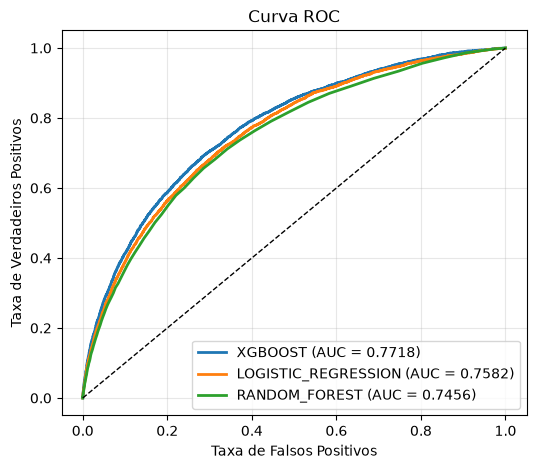

In [4]:
# --- CÉLULA 4: Comparação entre células método AUC/ROC--
plt.figure(figsize=(6, 5))
for model_name in df_resumo["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features(model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})', lw=2)

plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title(f'Curva ROC')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

AUC ROC Antes de utilizar a base de testes <br><br>
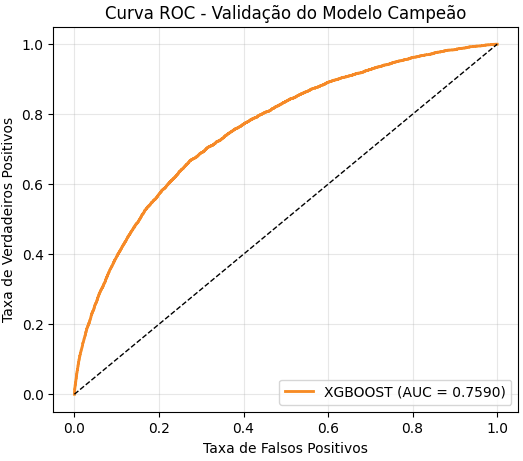

Carregando: models/XGBOOST/model.pkl
Carregando: models/LOGISTIC_REGRESSION/model.pkl
Carregando: models/RANDOM_FOREST/model.pkl


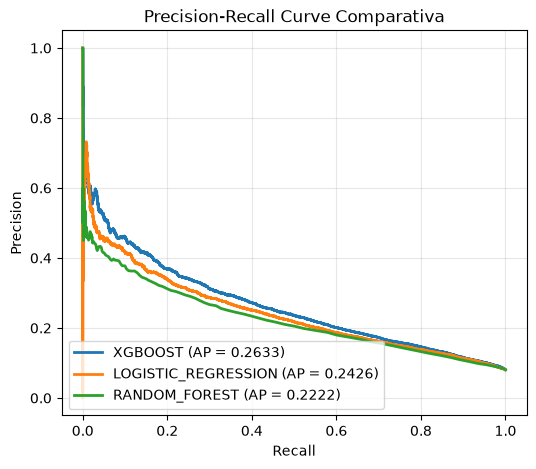

In [5]:
# --- CÉLULA 5: Precision-Recall Curve comparativa ---

plt.figure(figsize=(6, 5))
for model_name in df_resumo ["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features (model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]

    # Precision x Recall
    precision, recall, threshold = precision_recall_curve(y_test, probs)
    ap_score = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f'{model_name} (AP = {ap_score:.4f})', lw=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve Comparativa')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()


Carregando: models/XGBOOST/model.pkl


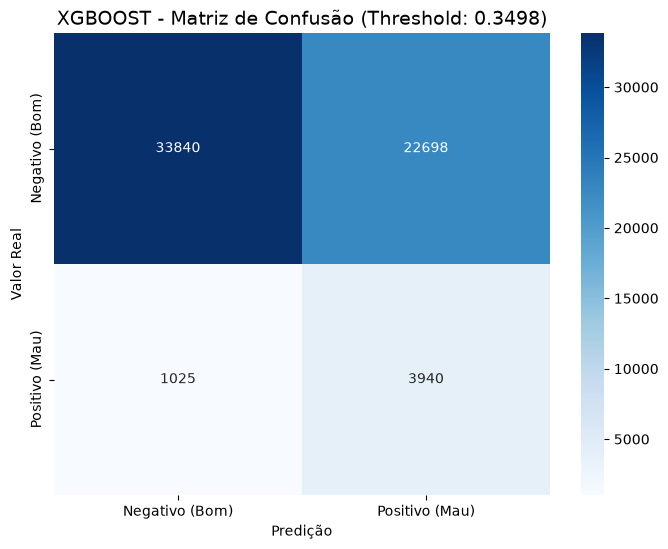

Carregando: models/LOGISTIC_REGRESSION/model.pkl


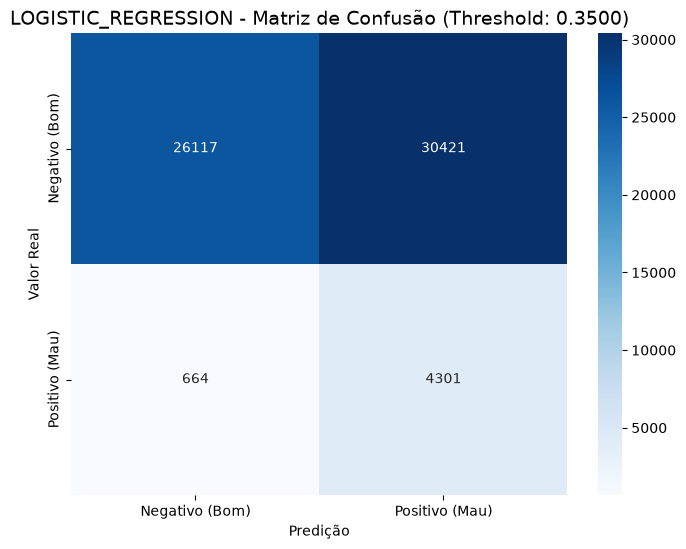

Carregando: models/RANDOM_FOREST/model.pkl


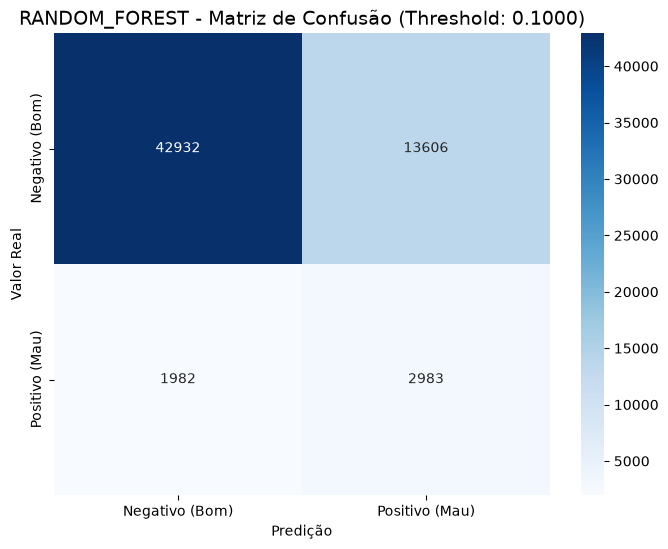

In [6]:
# --- CÉLULA 6: Matriz de Confusão ---

for model_name in df_resumo ["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features (model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    # plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negativo (Bom)', 'Positivo (Mau)'], 
                yticklabels=['Negativo (Bom)', 'Positivo (Mau)'])

    plt.title(f'{model_name} - Matriz de Confusão (Threshold: {threshold:.4f})', fontsize=14)
    plt.xlabel('Predição')
    plt.ylabel('Valor Real')
    plt.show()

In [7]:
# --- CÉLULA 7: Investigação de Viés por Fontes Externas ---
# Vamos comparar o EXT_SOURCE_2 (que geralmente é muito forte) 
# entre os Falsos Positivos e o resto da base.

fp_indices = (y_test == 0) & (y_pred == 1)
df_fp = X_test[fp_indices]
df_outros = X_test[~fp_indices]

print("--- Comparação de Fontes Externas ---")
print(f"Média EXT_SOURCE_2 nos Falsos Positivos: {df_fp['EXT_SOURCE_2'].mean():.4f}")
print(f"Média EXT_SOURCE_2 no restante da base: {df_outros['EXT_SOURCE_2'].mean():.4f}")

# Dica: Se a média dos FP for muito baixa, o modelo está "viciado" 
# em reprovar quem tem score baixo nessas fontes, ignorando que o DTI é bom.

--- Comparação de Fontes Externas ---
Média EXT_SOURCE_2 nos Falsos Positivos: 0.3769
Média EXT_SOURCE_2 no restante da base: 0.5540


Carregando: models/XGBOOST/model.pkl


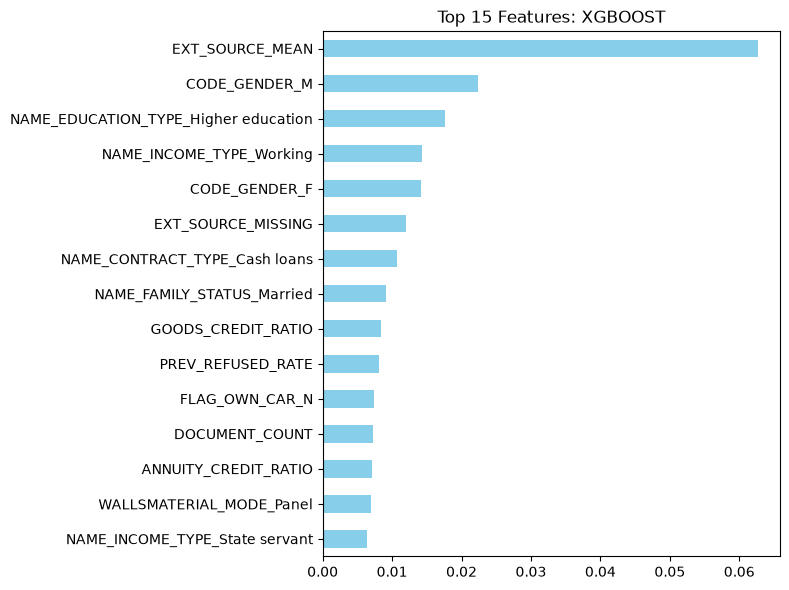

Carregando: models/LOGISTIC_REGRESSION/model.pkl


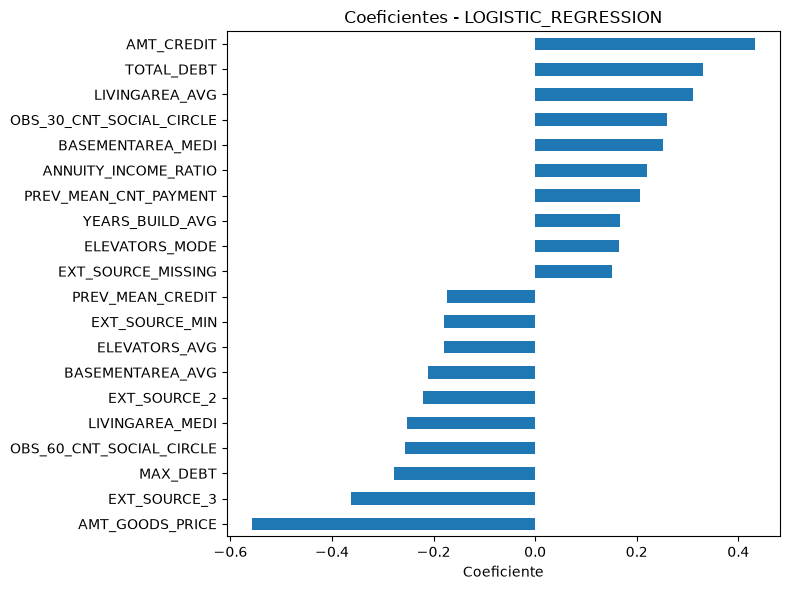

Carregando: models/RANDOM_FOREST/model.pkl


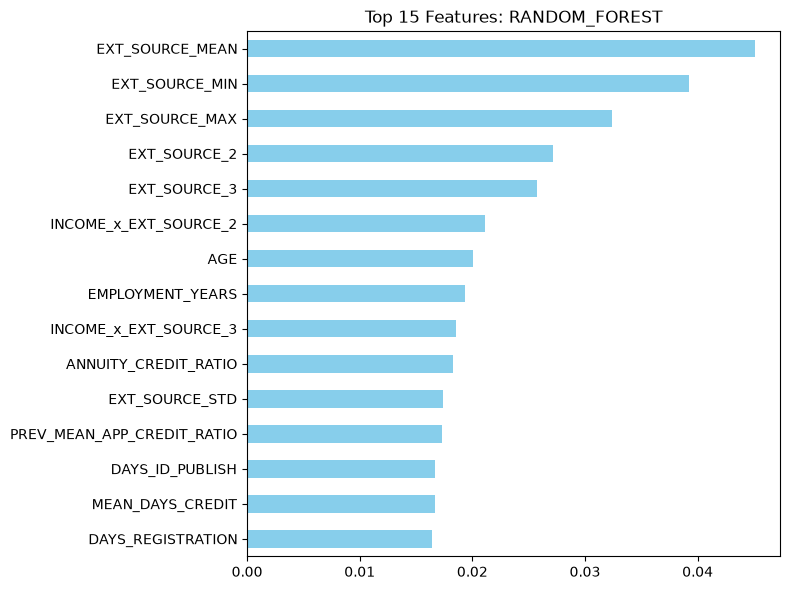

In [9]:
# --- CÉLULA 8: interpretabilidade específica ---

for model_name in df_resumo ["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    est = model.named_steps['model'] if isinstance(model, Pipeline) else model
    if model_name in ["XGBOOST","RANDOM_FOREST"]:
        if hasattr(est, 'feature_importances_'):
            imp = pd.Series(est.feature_importances_, index=feature_names).nlargest(15)
            plt.figure(figsize=(8, 6))
            imp.sort_values().plot(kind='barh', color='skyblue')
            plt.title(f'Top 15 Features: {model_name}')
            plt.tight_layout()
            plt.show()
            plt.close()

    else:       
        if hasattr(est, 'coef_'):
            coef = pd.Series(est.coef_[0], index=feature_names)

            top_positivos = coef.nlargest(10)
            top_negativos = coef.nsmallest(10)

            coef_plot = pd.concat([top_negativos, top_positivos])

            plt.figure(figsize=(8, 6))
            coef_plot.sort_values().plot(kind="barh")
            plt.title(f"Coeficientes - {model_name}")
            plt.xlabel("Coeficiente")
            plt.tight_layout()
            plt.show()
            plt.close()


In [10]:
# --- CÉLULA 9: Conclusão ---
display(df_resumo)
best_model = df_resumo.iloc[0]
# Extrair principais métricas
nome_modelo = best_model["Modelo"]
roc_auc = best_model["ROC AUC"]
acuracia = best_model["Acurácia"]
precisao = best_model["Precisão"]
recall = best_model["Recall"]
f1 = best_model["F1"]
threshold = best_model["Threshold"]
#Exibir resumo do modelo campeão
print("=== Modelo Campeão ===")
print(f"Modelo: {best_model}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Threshold: {threshold:.4f}")
#Texto final interpretativo
print("\n=== Conclusão ===")
print(
    f"O modelo com melhor desempenho geral foi o {best_model}, "
    f"apresentando ROC AUC de {roc_auc:.4f}. "
    "A escolha considera principalmente a capacidade de separação entre bons e maus pagadores, "
    "além do equilíbrio observado entre precisão, recall e F1-score."
)

,Modelo,ROC AUC,Acurácia,Precisão,Recall,F1,Threshold
0,XGBOOST,0.771782,0.614279,0.147909,0.793555,0.249343,0.349770
2,LOGISTIC_REGRESSION,0.758208,0.494578,0.123870,0.866264,0.216746,0.349997
1,RANDOM_FOREST,0.745601,0.746549,0.179818,0.600806,0.276793,0.100000


=== Modelo Campeão ===
Modelo: Modelo        XGBOOST
ROC AUC      0.771782
Acurácia     0.614279
Precisão     0.147909
Recall       0.793555
F1           0.249343
Threshold     0.34977
Name: 0, dtype: object
ROC AUC: 0.7718
Acurácia: 0.6143
Precisão: 0.1479
Recall: 0.7936
F1-score: 0.2493
Threshold: 0.3498

=== Conclusão ===
O modelo com melhor desempenho geral foi o Modelo        XGBOOST
ROC AUC      0.771782
Acurácia     0.614279
Precisão     0.147909
Recall       0.793555
F1           0.249343
Threshold     0.34977
Name: 0, dtype: object, apresentando ROC AUC de 0.7718. A escolha considera principalmente a capacidade de separação entre bons e maus pagadores, além do equilíbrio observado entre precisão, recall e F1-score.
